# CNN Multi Dim Analysis

## 16-jan-2026

### Imports

In [3]:
%matplotlib widget

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch

from pathlib import Path

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *

RANDOM_STATE = 42


atoms = ["N", "CA", "C", "O", 'CB']

mean = json.load(open("../data/data_statistics_full.json"))["mean"]
std = json.load(open("../data/data_statistics_full.json"))["std"]

data_closed = PDBData(
    filename=["../data/full_murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["../data/full_murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full_murd_closed_open_1.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_test.prepare_dataset(mean=mean, std=std)



Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([200, 2145, 3])


### Loading Datasets and results

In [4]:
log_dfs = {}
min_valid_losses = {}
min_valid_mse_losses = {}
models = {}
MAs = {}

base_path = r"../results/11-feb-2026-latent-dim-n"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for n in [2,3,4,5]:

    log_dfs[n] = pd.read_csv(Path(f"{base_path}/{n}/log.dat"))
    best_epoch = log_dfs[n]['valid_loss'].idxmin()
    min_valid_losses[n] = min(log_dfs[n].valid_loss)
    min_valid_mse_losses[n] = min(log_dfs[n].valid_mse_loss)

    checkpoint_path = Path(f"{base_path}/{n}/checkpoint_converged.ckpt")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = AutoEncoder(n_atoms=data_open.dataset.shape[1], latent_dim=n)
    model.load_state_dict(checkpoint['model_state_dict'])

    models[n] = model

    MA = MolearnAnalysis() 
    MA.batch_size = 16
    MA.processes = 4

    MA.set_dataset(data=data_open, key="train_open")
    MA.set_dataset(data=data_closed, key="train_closed")
    MA.set_dataset(data=data_test, key="test_trans")

    MA.set_network(models[n])

    MAs[n] = MA

### Model architecture and shapes

In [5]:
from molearn.models.CNN_autoencoder import ToND, FromND
from torch import nn


def print_encoder_shapes(model, n_atoms):
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x = torch.randn(1, n_atoms, 3)
    
    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")
    
    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal latent shape: {x.shape}")
    return x

# Test with your model

latent_dim = 3

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={latent_dim}")
print("=" * 60)
z = print_encoder_shapes(models[latent_dim], n_atoms=data_open.dataset.shape[1])
print(data_open.dataset.shape)

ENCODER FORWARD PASS - latent_dim=3
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 3])

Final latent shape: torch.Size([1, 3])
torch.Size([2000, 2145, 3])


In [7]:
def print_decoder_shapes(model, latent_dim):
    """Print the shape at each stage of the decoder"""
    # Create dummy latent input: (batch=1, latent_dim)
    x = torch.randn(1, latent_dim)
    print(f"Input latent shape: {x.shape}")
    
    for i, m in enumerate(model.decoder):
        x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal output shape: {x.shape}")
    return x

# Test with your model
latent_dim = 2

print("=" * 60)
print(f"DECODER FORWARD PASS - latent_dim={latent_dim}")
print("=" * 60)
decoded = print_decoder_shapes(models[latent_dim], 2)
print(f"\nExpected atoms: {data_open.dataset.shape[1]}")
print(f"Decoder output atoms: {decoded.shape[2]}")
print(f"Difference: {decoded.shape[2] - data_open.dataset.shape[1]} atoms discarded")

DECODER FORWARD PASS - latent_dim=2
Input latent shape: torch.Size([1, 2])
Layer 0 (FromND): torch.Size([1, 1, 17])
Layer 1 (ConvTranspose1d): torch.Size([1, 243, 34])
Layer 4 (ConvTranspose1d): torch.Size([1, 162, 68])
Layer 7 (ConvTranspose1d): torch.Size([1, 108, 136])
Layer 10 (ConvTranspose1d): torch.Size([1, 72, 272])
Layer 13 (ConvTranspose1d): torch.Size([1, 48, 544])
Layer 16 (ConvTranspose1d): torch.Size([1, 32, 1088])
Layer 19 (ConvTranspose1d): torch.Size([1, 3, 2176])

Final output shape: torch.Size([1, 3, 2176])

Expected atoms: 2145
Decoder output atoms: 2176
Difference: 31 atoms discarded


### MSE Plots 

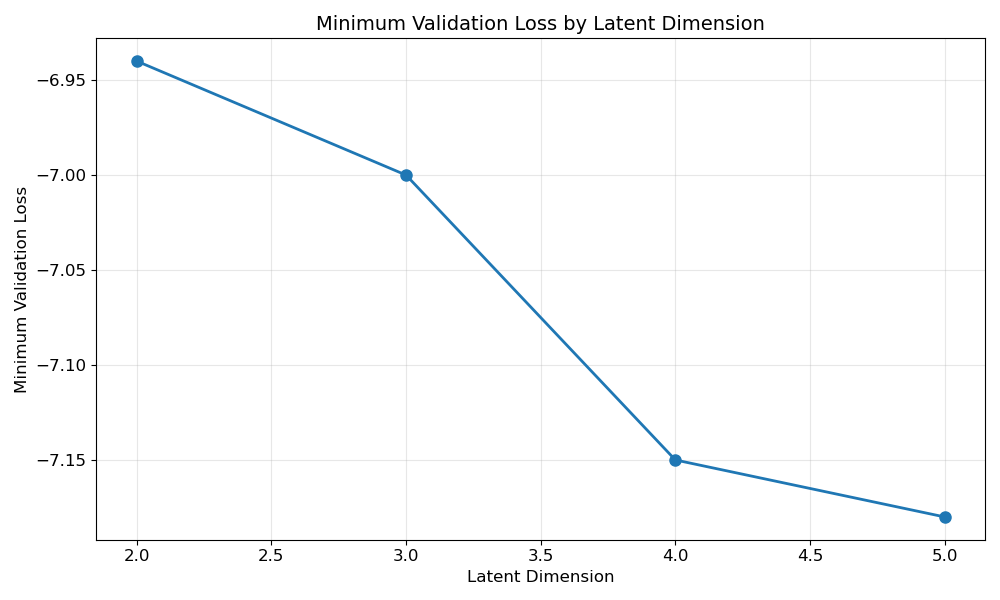

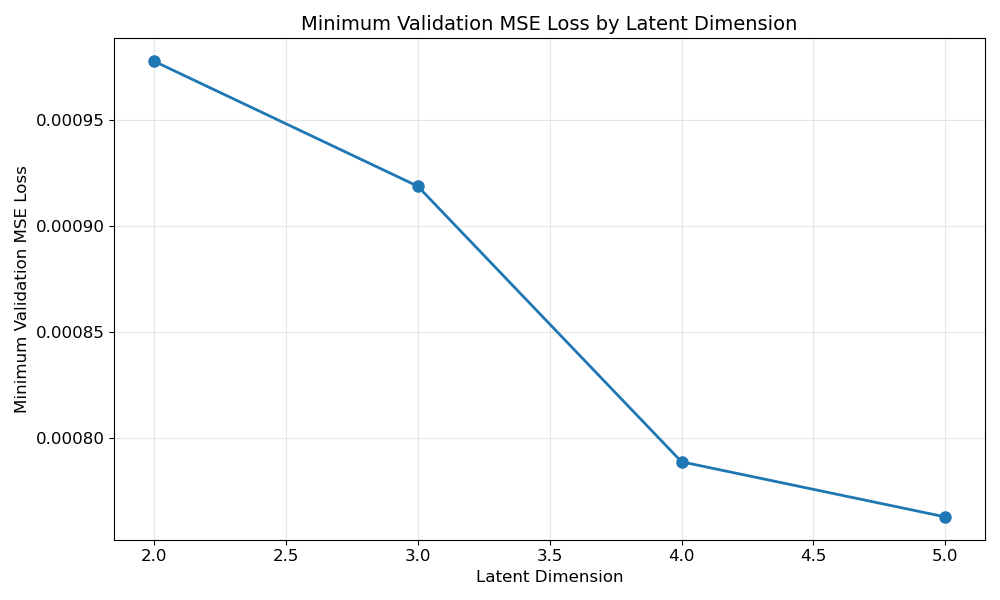

In [8]:
# Plot line graph of minimum validation losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_losses.keys()), list(min_valid_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot line graph of minimum validation MSE_losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_mse_losses.keys()), list(min_valid_mse_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation MSE Loss', fontsize=12)
plt.title('Minimum Validation MSE Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Model plots

#### RMSD Hist plot

encoding train_open: 0it [00:00, ?it/s]

encoding train_open: 125it [00:00, 156.30it/s]
Decoding train_open: 125it [00:01, 102.41it/s]
encoding train_closed: 125it [00:00, 271.47it/s]
Decoding train_closed: 125it [00:00, 154.80it/s]
encoding test_trans: 13it [00:00, 249.05it/s]
Decoding test_trans: 13it [00:00, 43.22it/s]


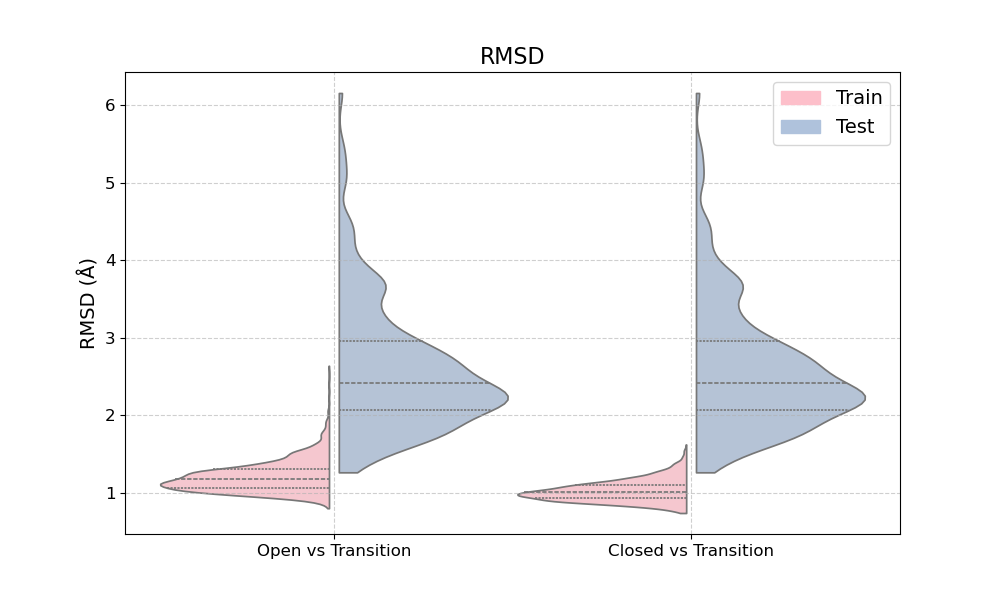

encoding train_open: 125it [00:00, 237.74it/s]
Decoding train_open: 125it [00:00, 154.25it/s]
encoding train_closed: 125it [00:00, 244.75it/s]
Decoding train_closed: 125it [00:00, 158.68it/s]
encoding test_trans: 13it [00:00, 271.12it/s]
Decoding test_trans: 13it [00:00, 185.57it/s]


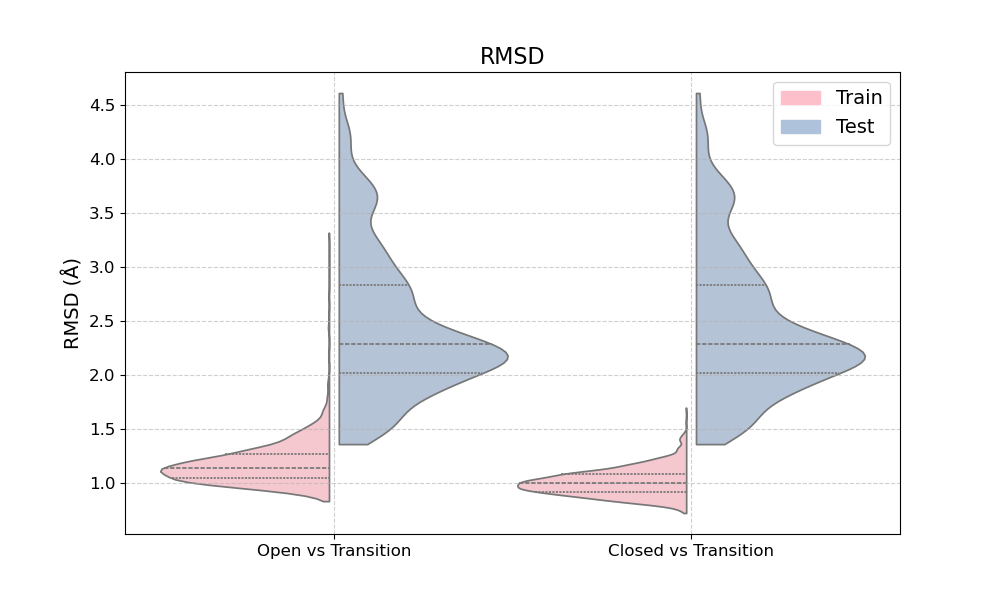

encoding train_open: 125it [00:00, 193.78it/s]
Decoding train_open: 125it [00:00, 164.21it/s]
encoding train_closed: 125it [00:00, 238.77it/s]
Decoding train_closed: 125it [00:00, 159.97it/s]
encoding test_trans: 13it [00:00, 272.55it/s]
Decoding test_trans: 13it [00:00, 169.59it/s]


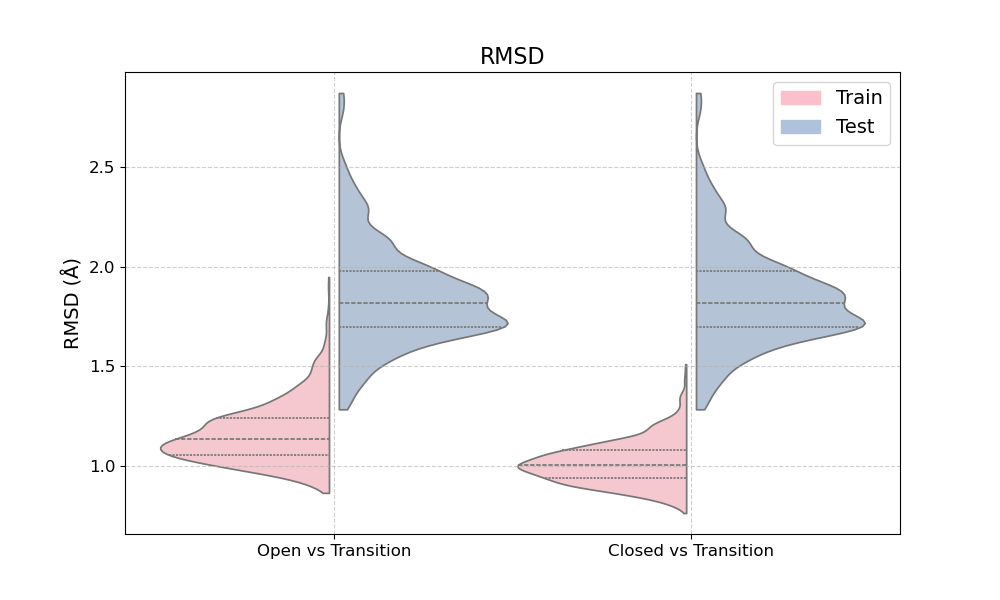

encoding train_open: 125it [00:00, 220.33it/s]
Decoding train_open: 125it [00:00, 162.07it/s]
encoding train_closed: 125it [00:00, 238.27it/s]
Decoding train_closed: 125it [00:00, 156.01it/s]
encoding test_trans: 13it [00:00, 187.38it/s]
Decoding test_trans: 13it [00:00, 130.63it/s]


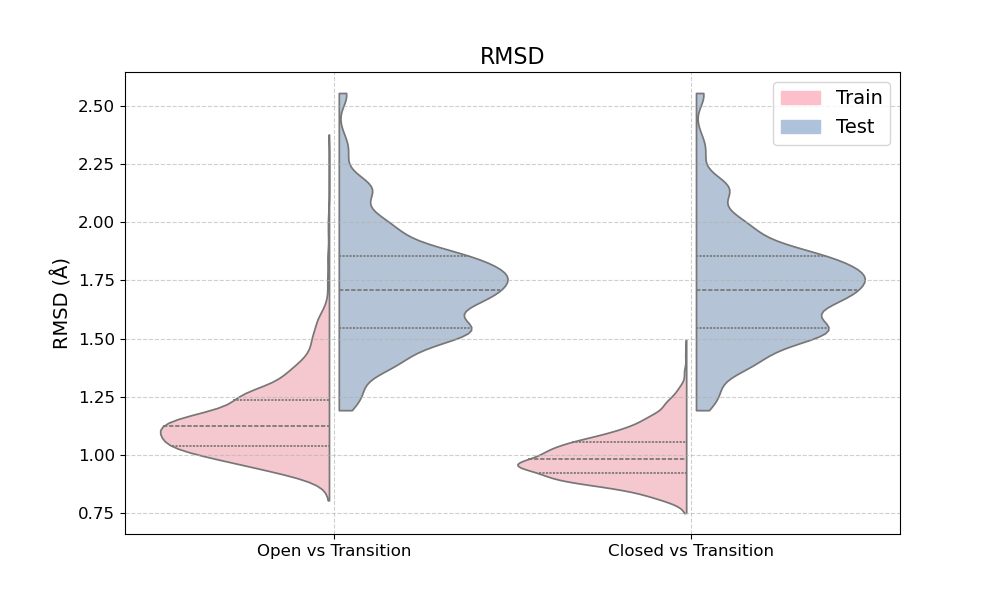

In [10]:
from molearn.analysis.plot import plot_rmsd_hist

test_vars = [2, 3, 4, 5]

for var in test_vars:
    rmsd_train_open = MAs[var].get_error('train_open')
    rmsd_train_closed = MAs[var].get_error('train_closed')
    rmsd_test_trans = MAs[var].get_error('test_trans')

    rmsd_plot_data = [
        ("train_open", "test_trans", "Open vs Transition", "train", "test"),
        ("train_closed", "test_trans", "Closed vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[var],
        plot_data=rmsd_plot_data,
        dpi=150,
        latent_dim=2,
    )

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=2


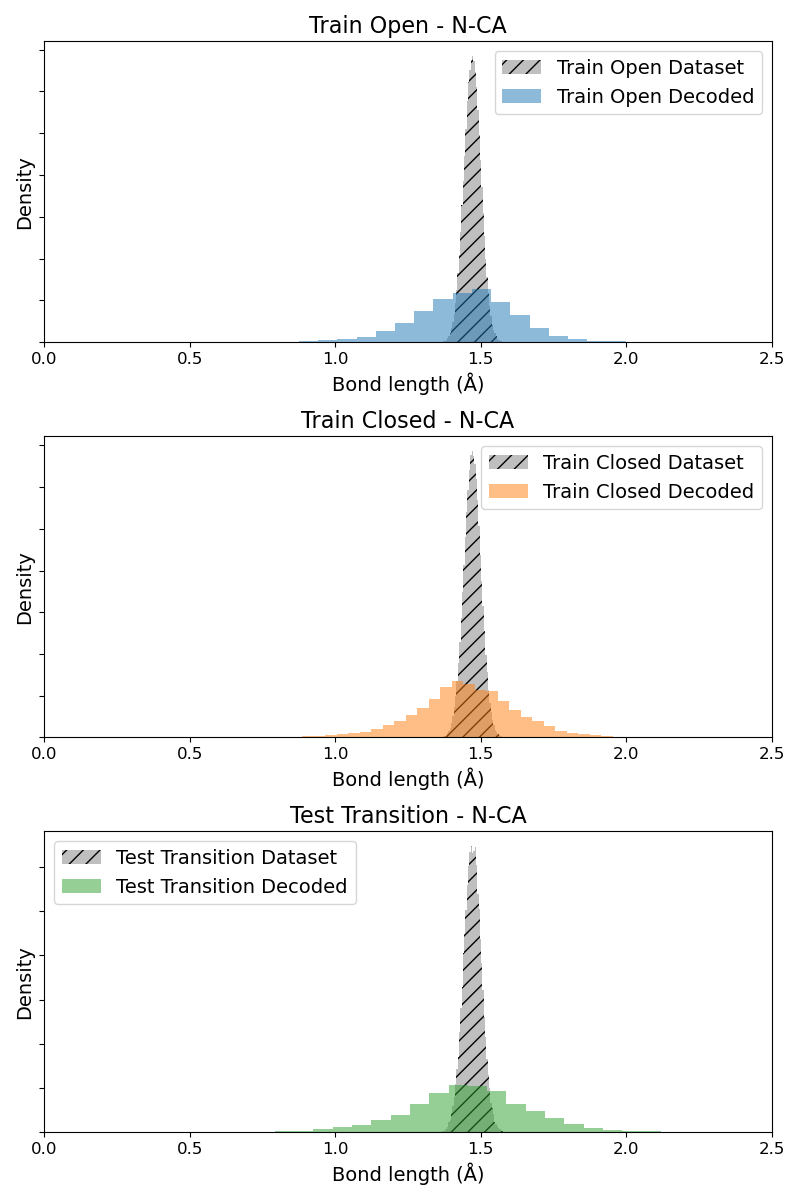

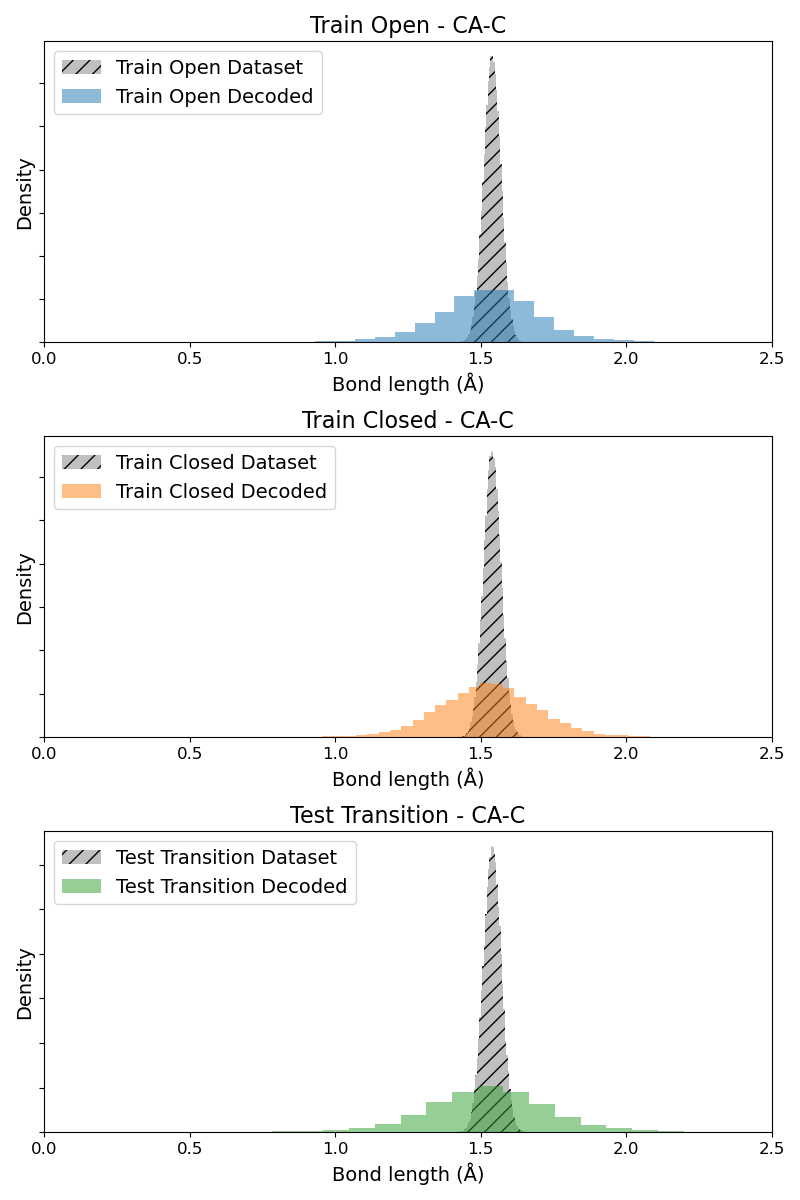

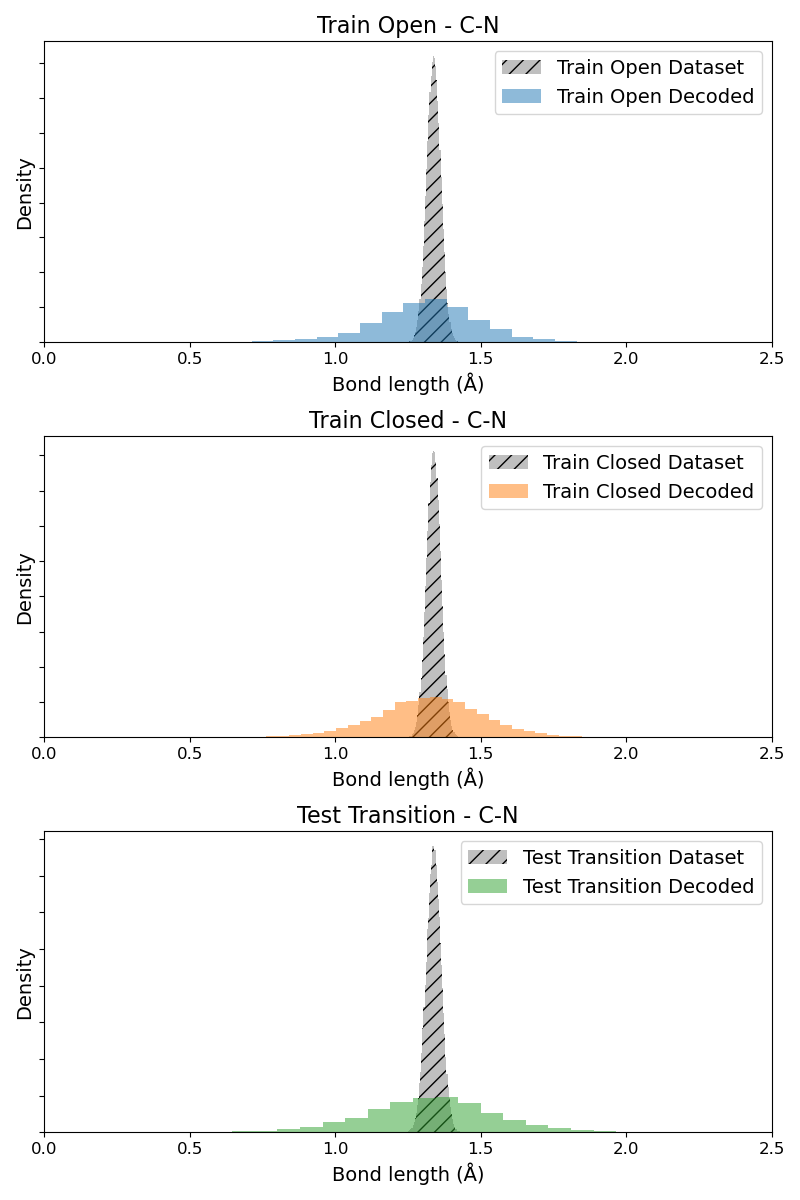

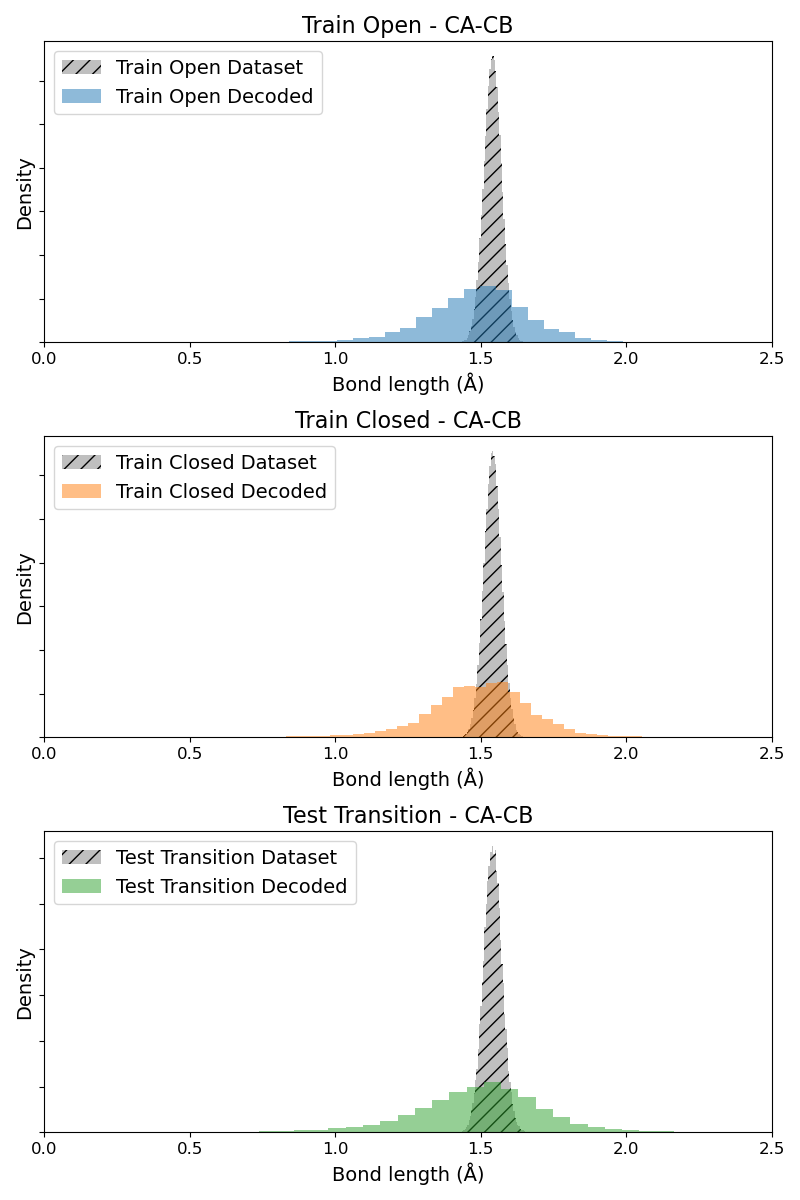

BOND LENGTH DISTRIBUTIONS - latent_dim=3


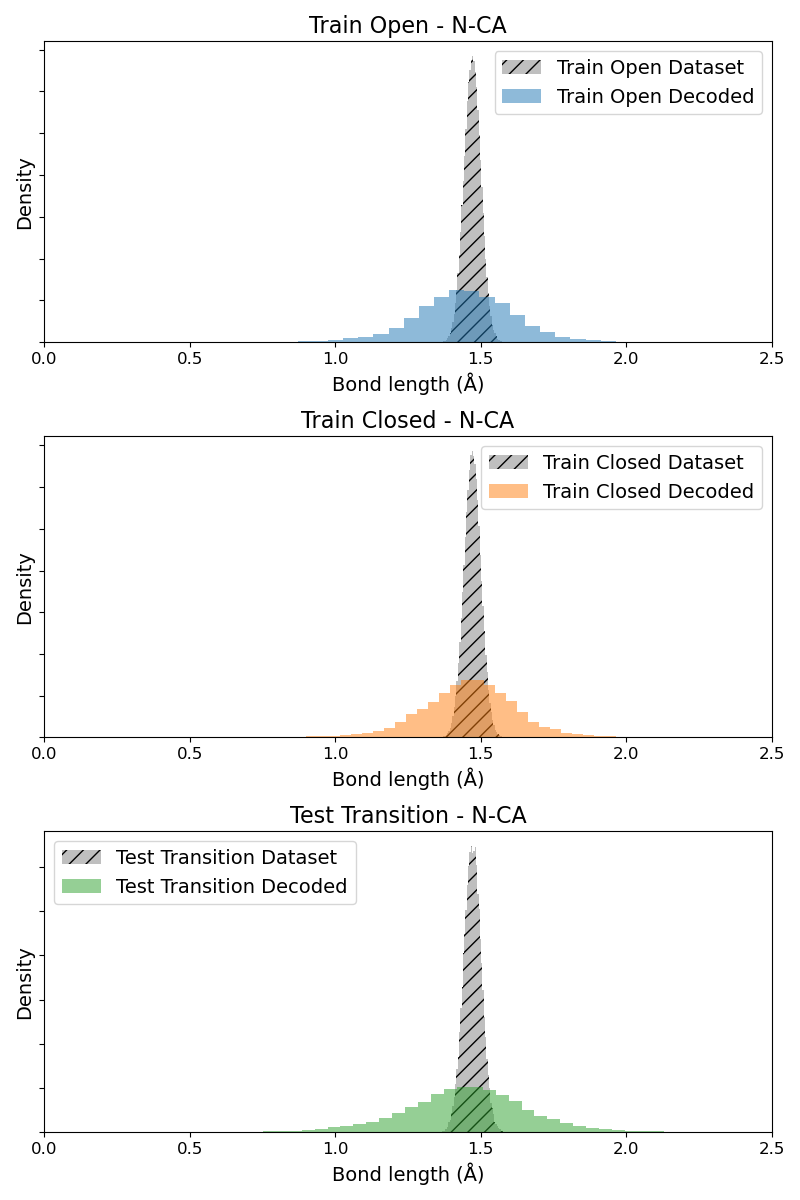

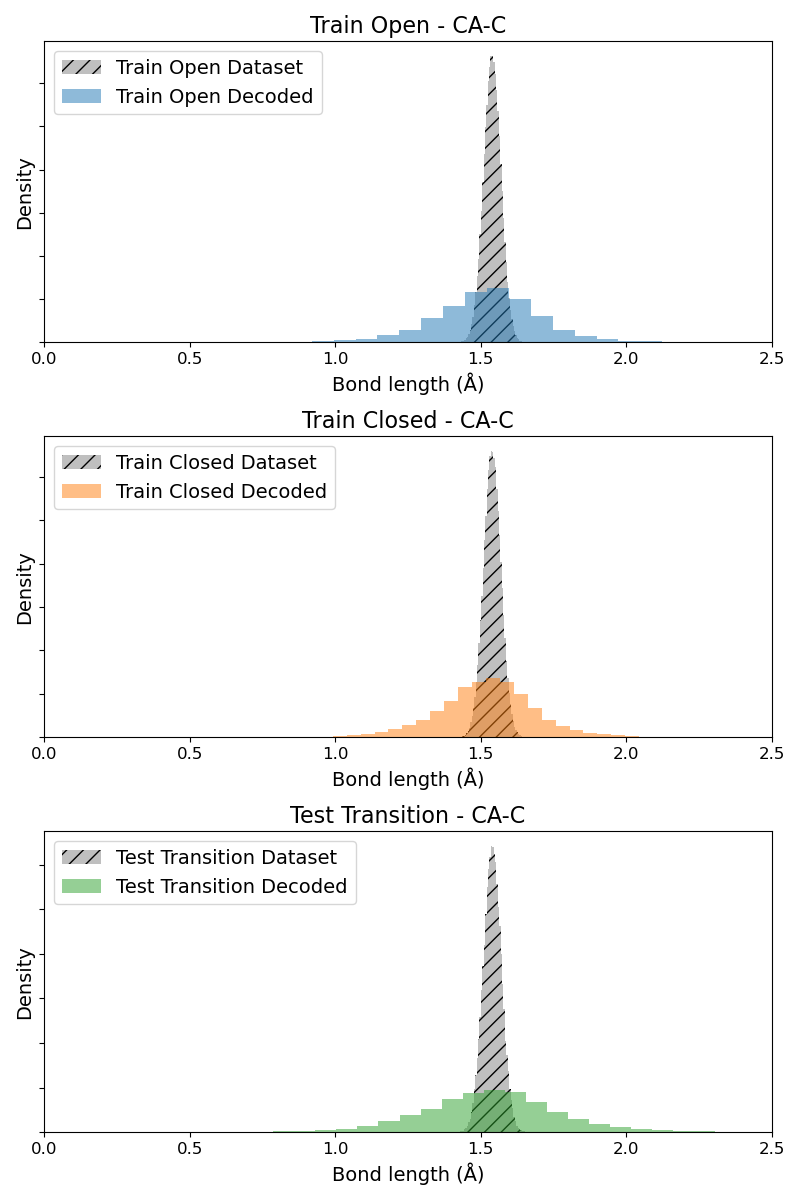

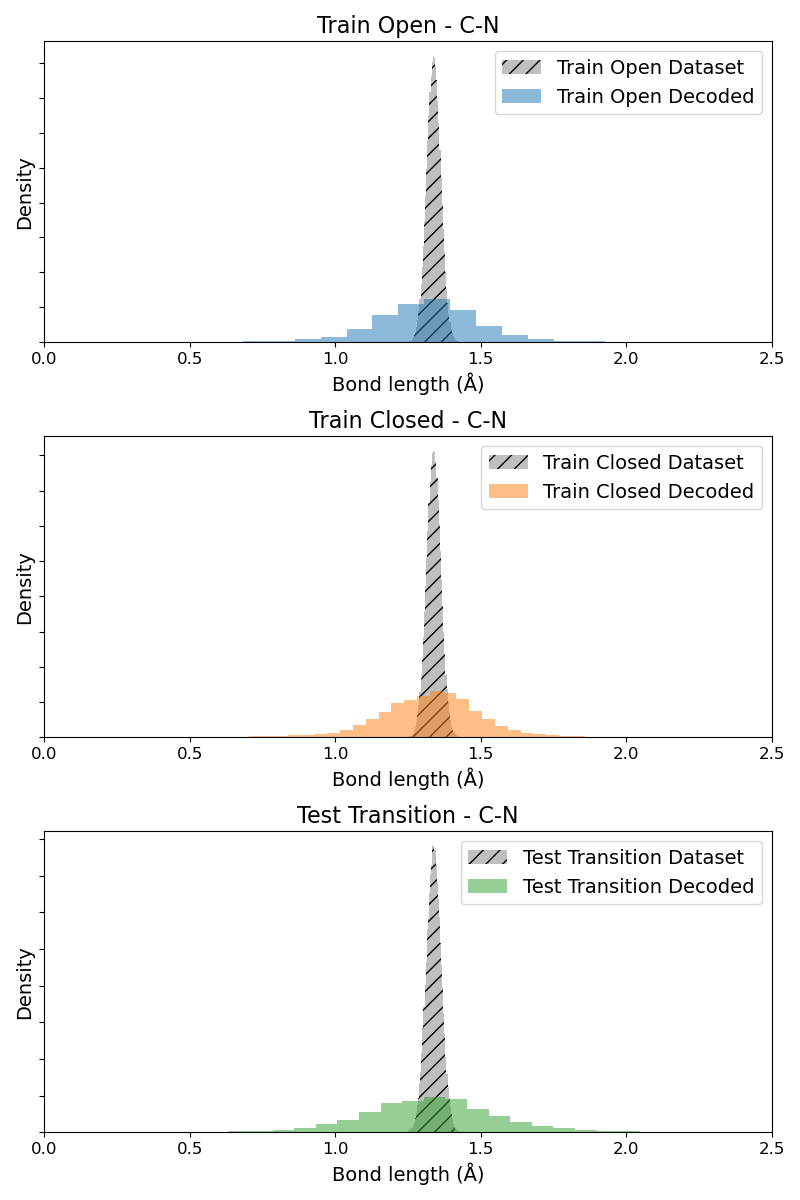

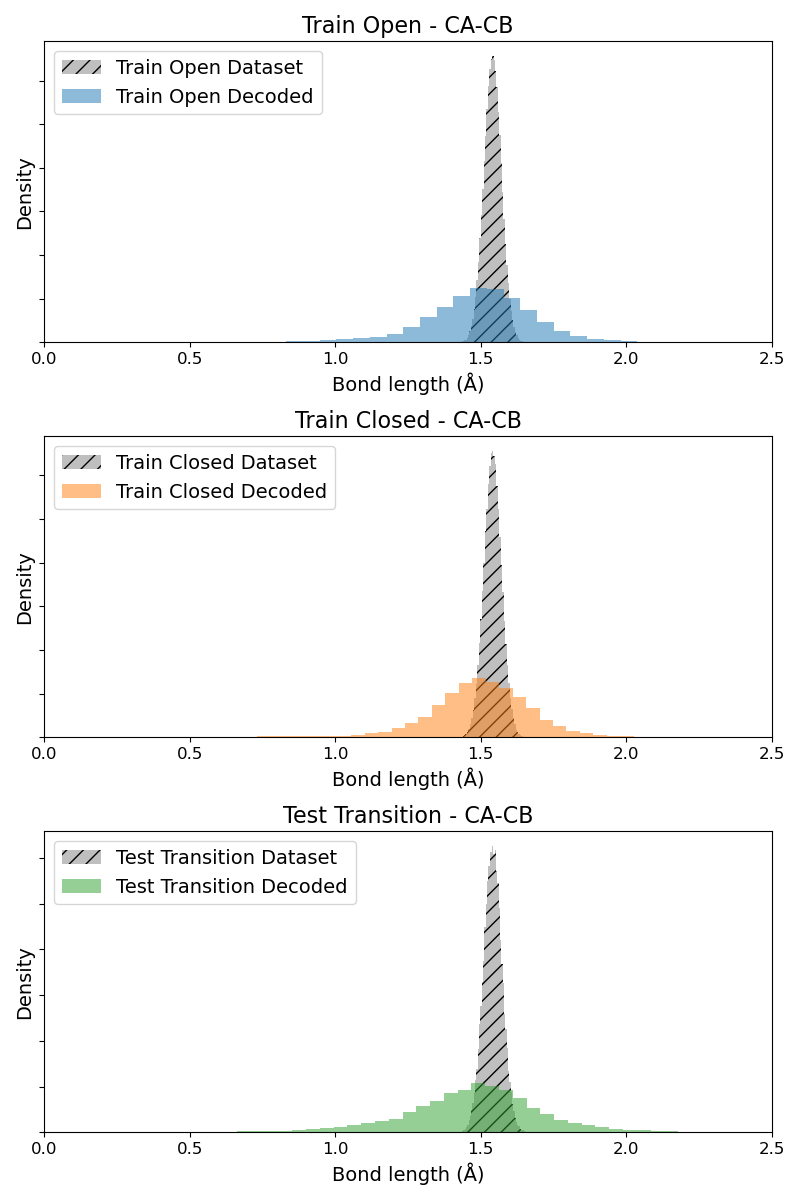

BOND LENGTH DISTRIBUTIONS - latent_dim=4


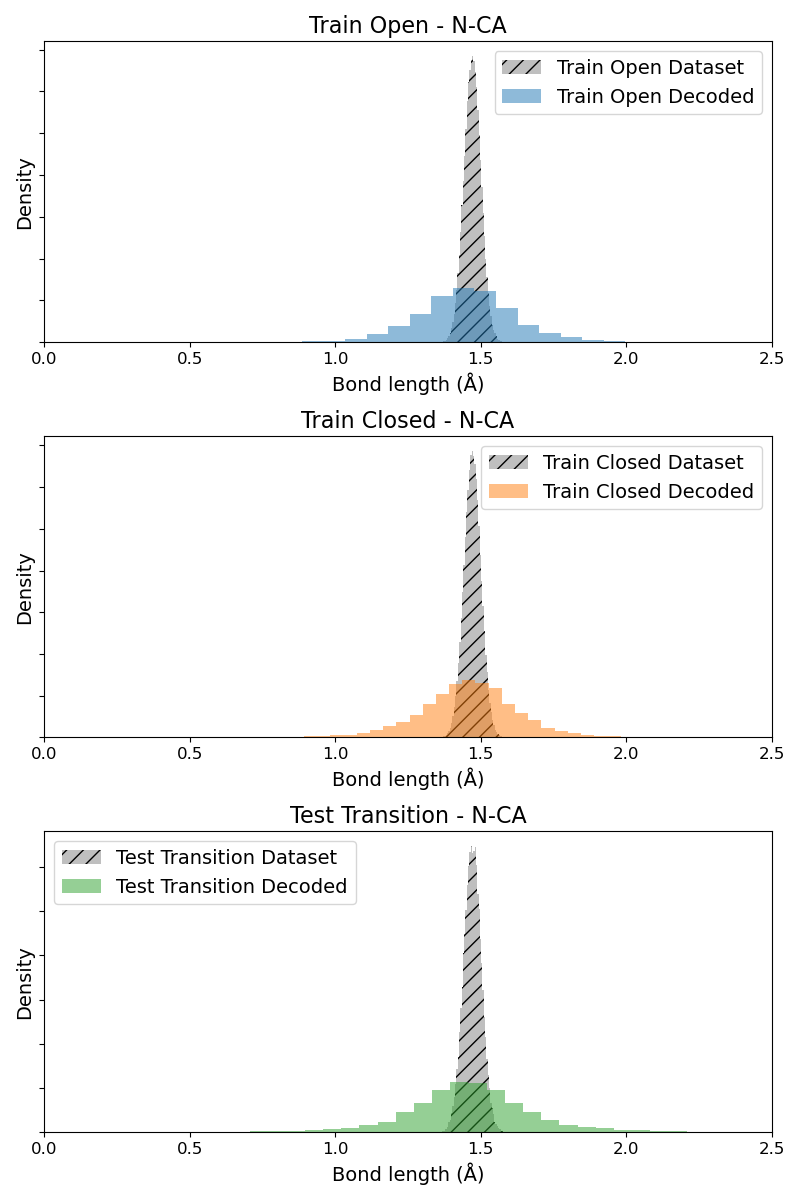

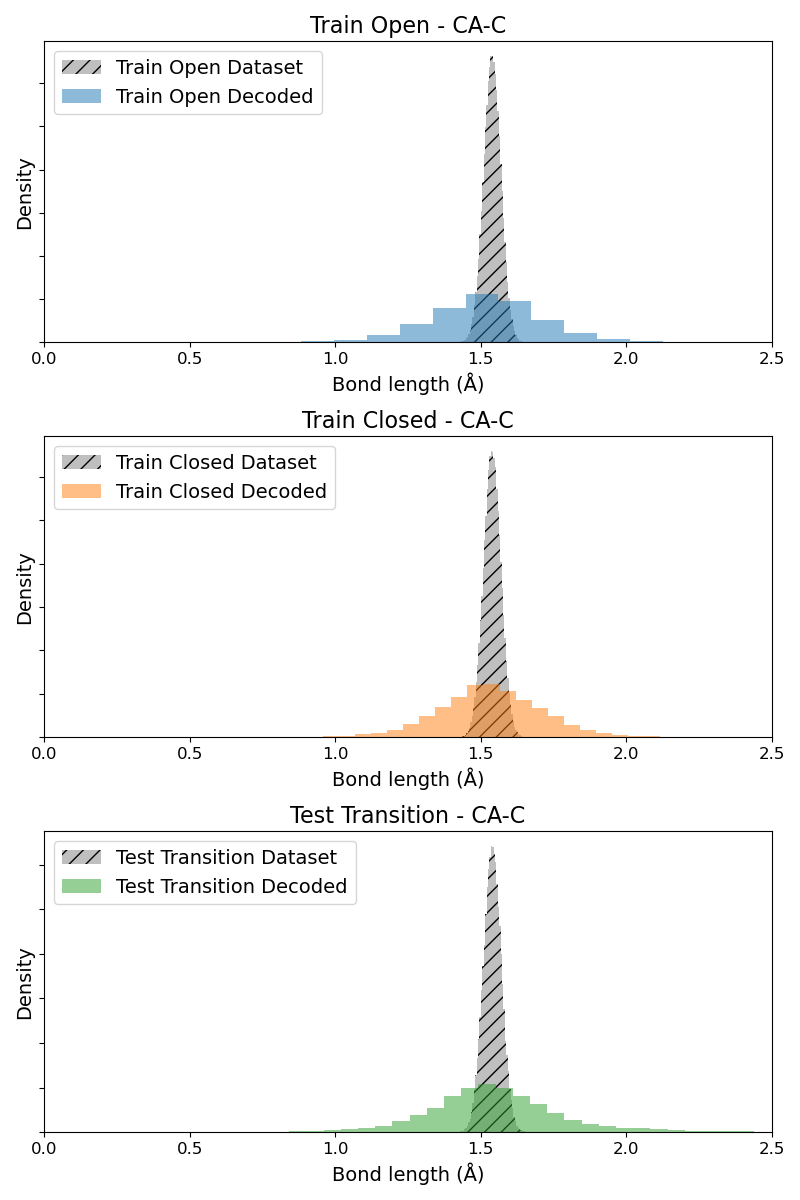

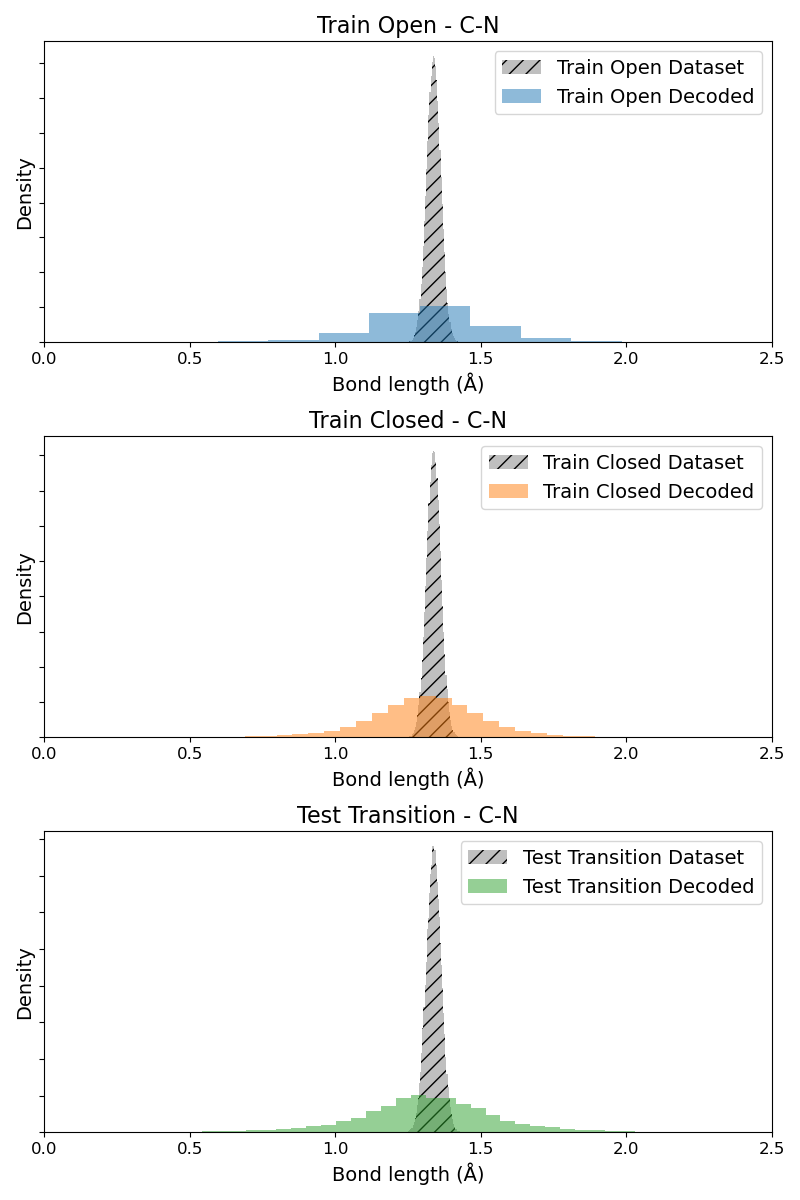

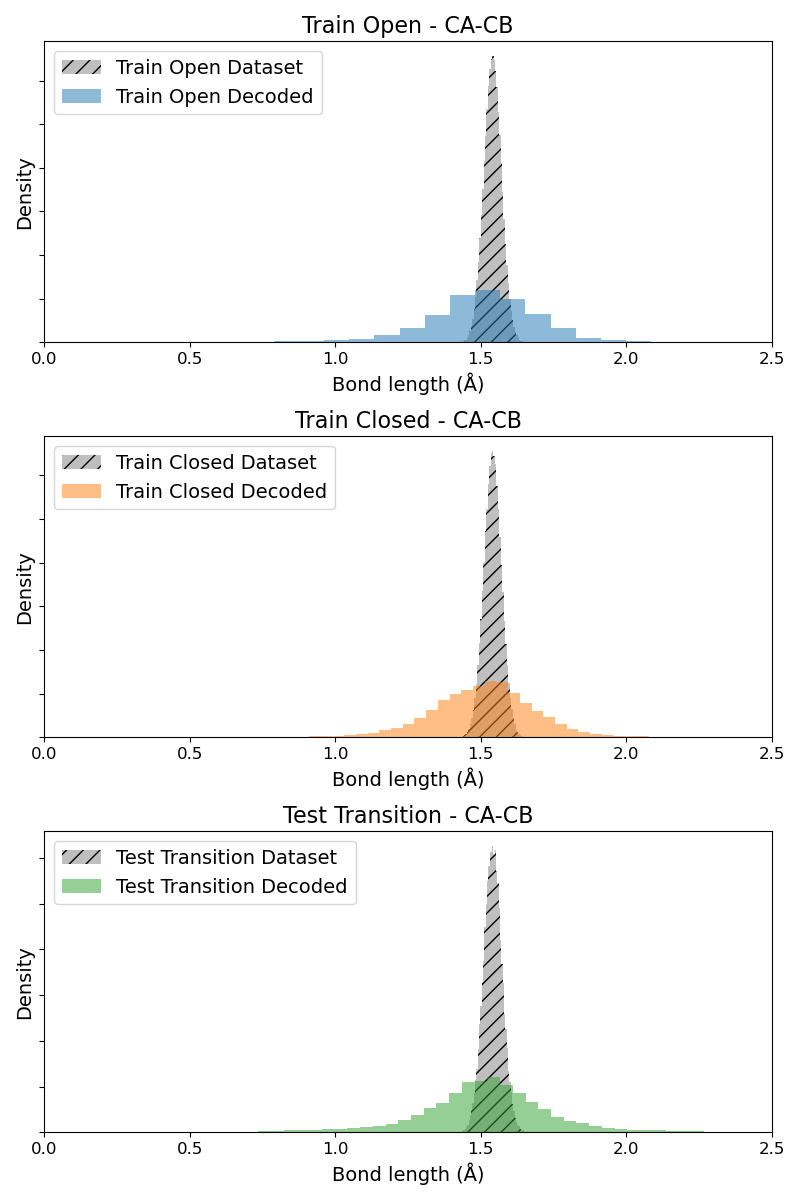

BOND LENGTH DISTRIBUTIONS - latent_dim=5


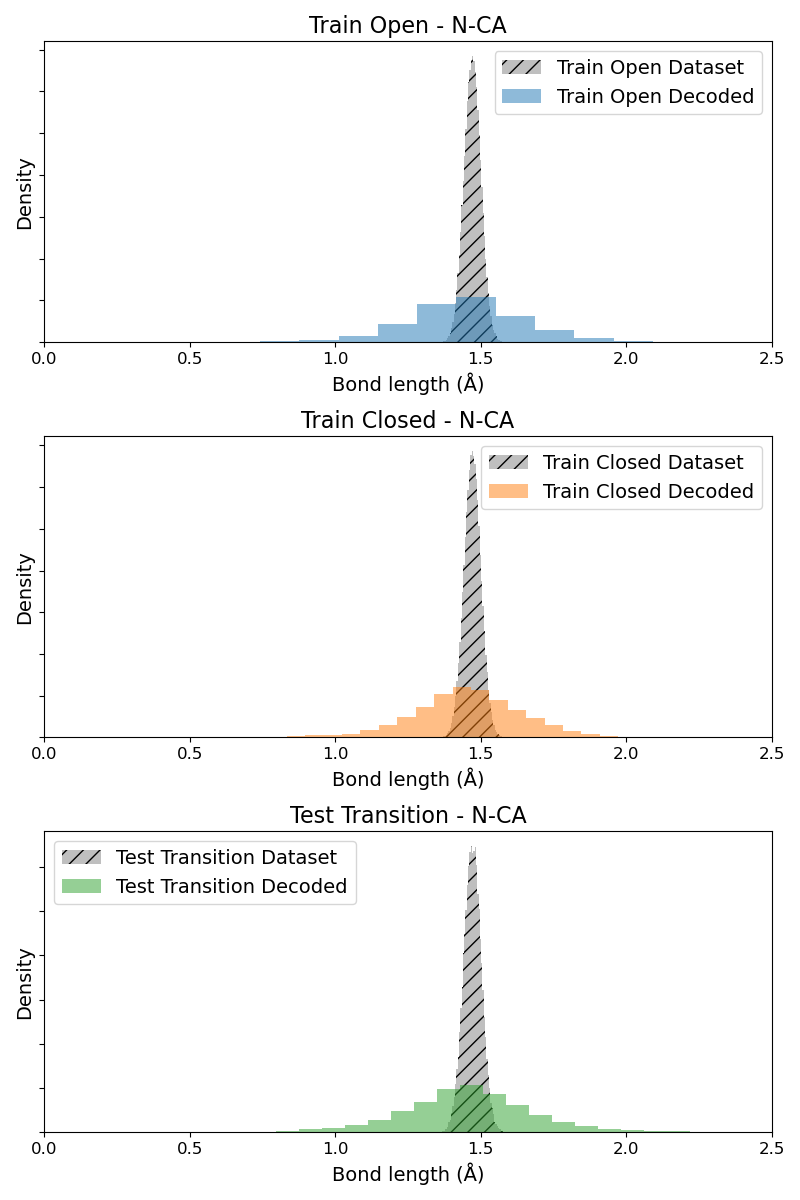

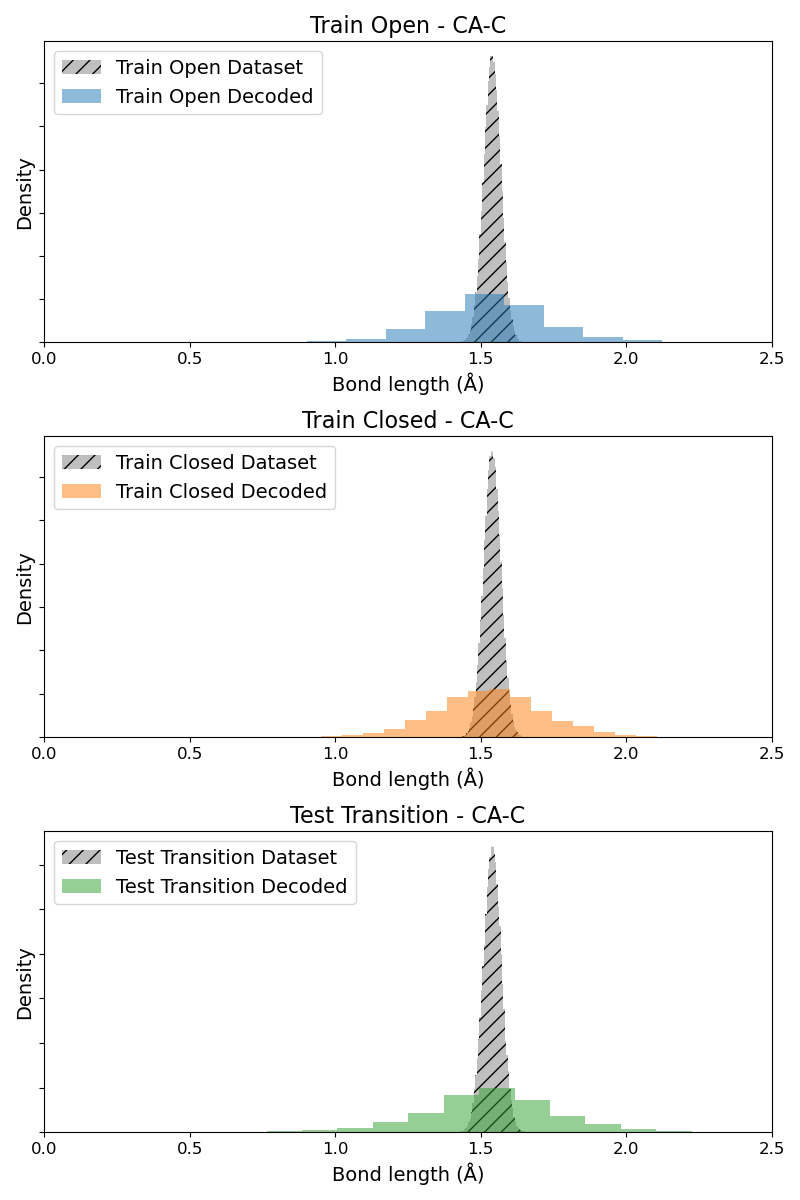

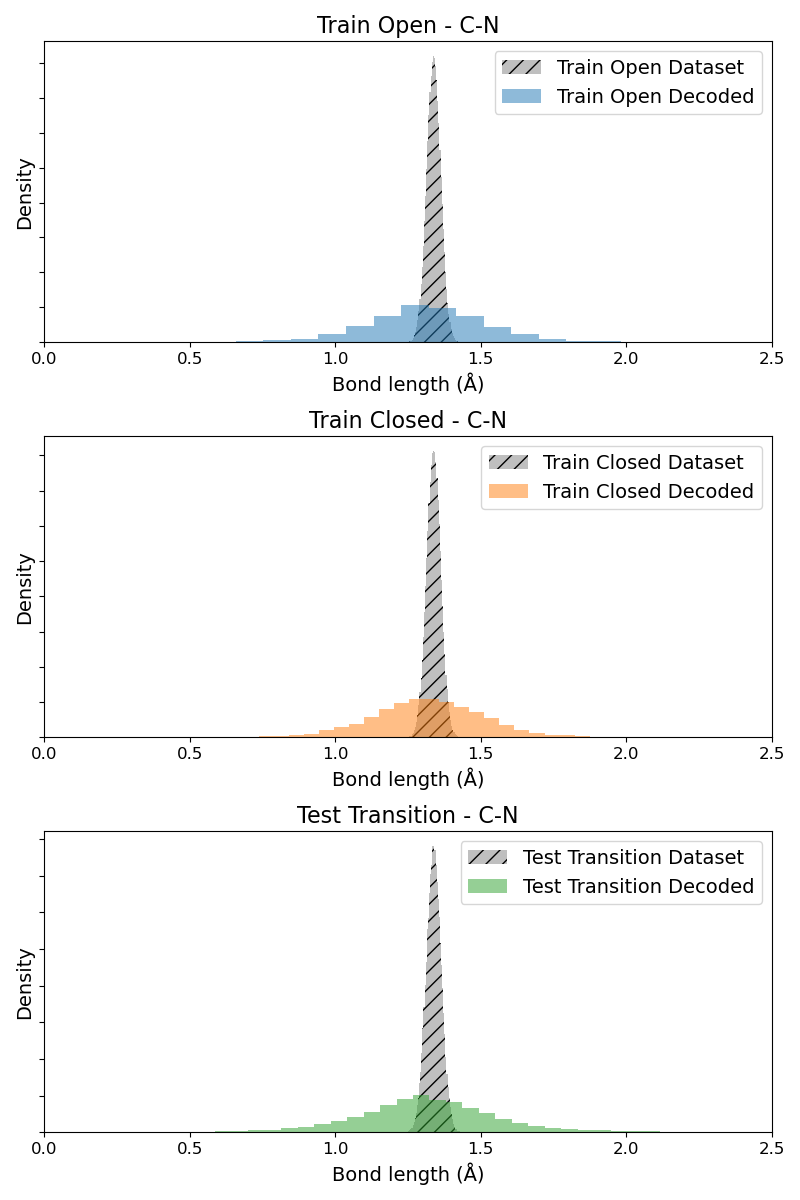

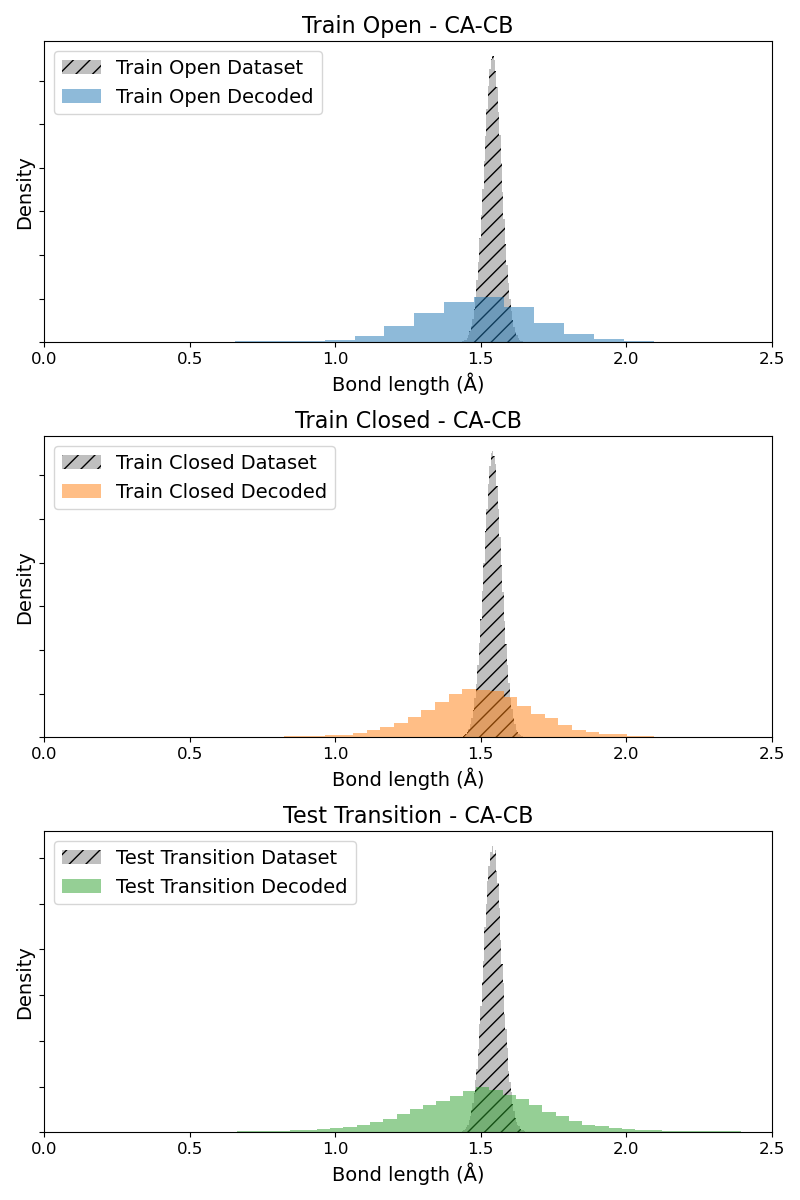

In [11]:
%load_ext autoreload
%autoreload 2

from molearn.analysis.plot import plot_bondlength_hist

for latent_dim in test_vars:

    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={latent_dim}")
    print("=" * 60)
    
    bondlength_train_open = MAs[latent_dim].get_bondlengths('train_open')
    bondlength_train_closed = MAs[latent_dim].get_bondlengths('train_closed')
    bondlength_test_trans = MAs[latent_dim].get_bondlengths('test_trans')

    bondlength_plot_data = [
        ("train_open", "Train Open", "#1f77b4"),
        ("train_closed", "Train Closed", "#ff7f0e"),
        ("test_trans", "Test Transition", "#2ca02c"),
    ]

    plot_bondlength_hist(
        MAs[latent_dim],
        plot_data=bondlength_plot_data,
        bins=60,
        dpi=150,
    )

#### Inversion Hist Plot

INVERSION ERRORS - latent_dim=2


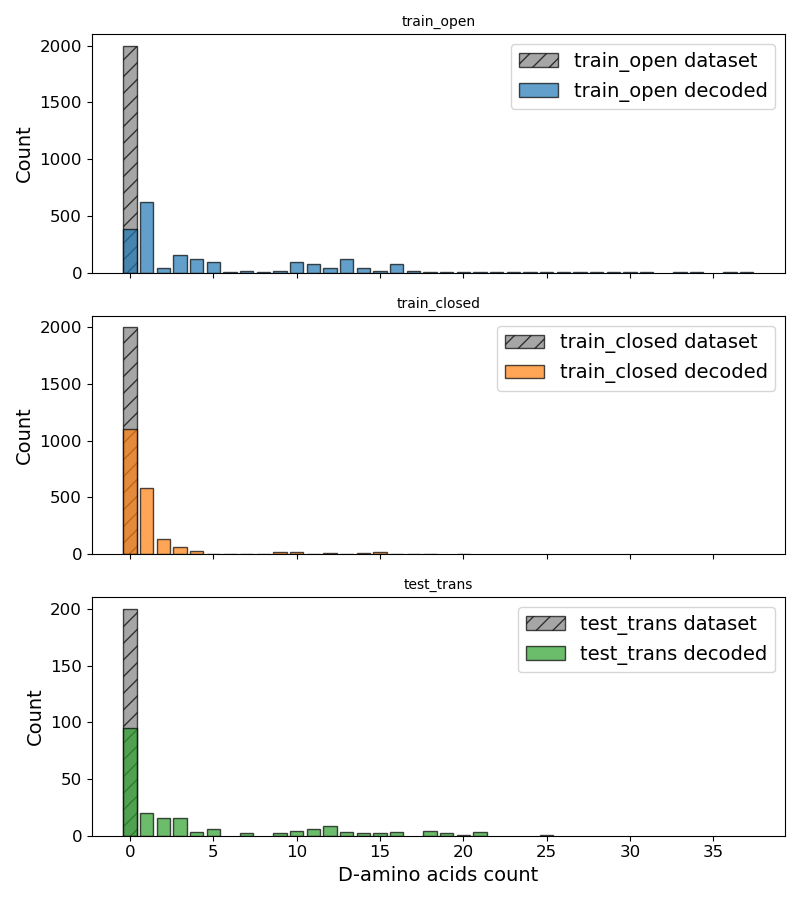

INVERSION ERRORS - latent_dim=5


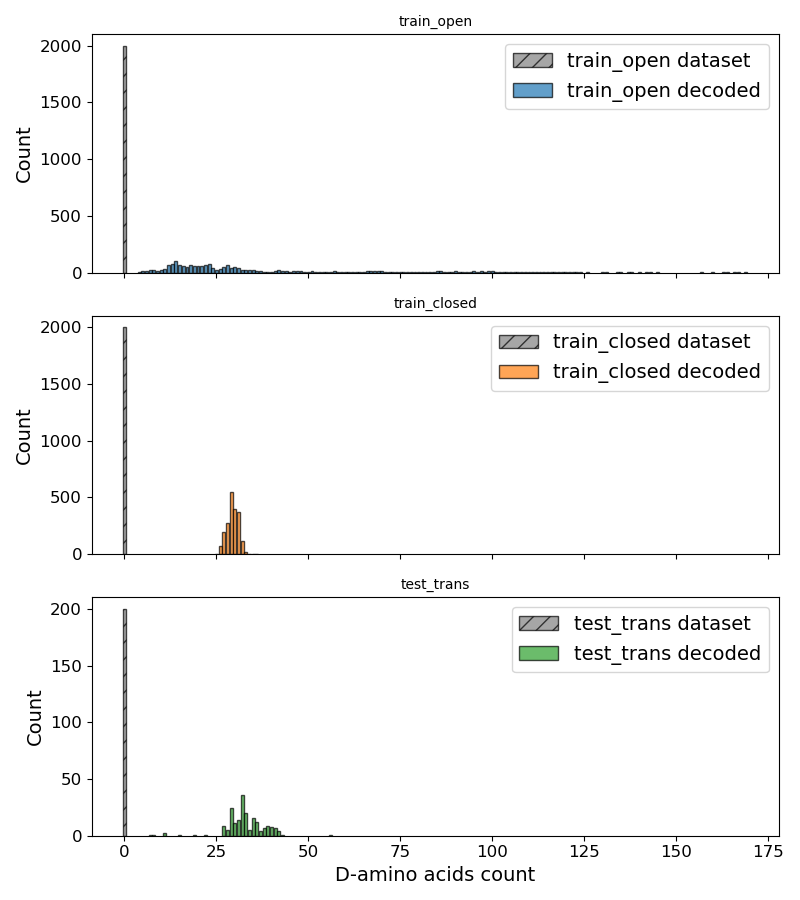

INVERSION ERRORS - latent_dim=9


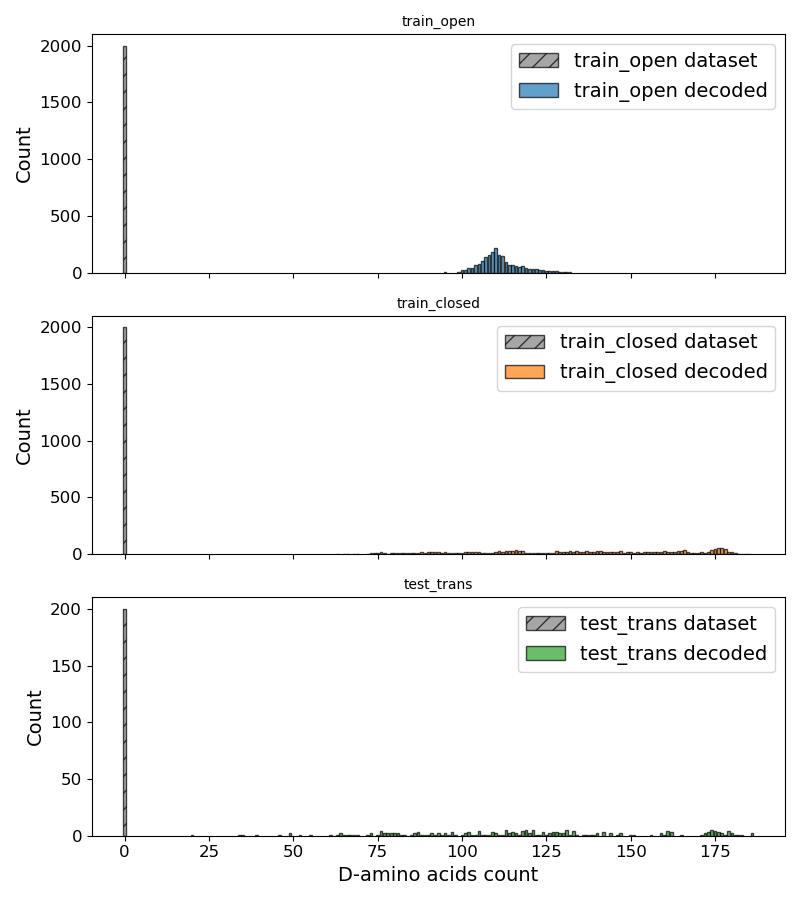

In [ ]:
inversion_plot_data = [('train_open', 'train_open', "#1f77b4"),
                       ('train_closed', 'train_closed',"#ff7f0e"),
                       ('test_trans', 'test_trans', "#2ca02c")]

for latent_dim in test_vars:
    print("=" * 60)
    print(f"INVERSION ERRORS - latent_dim={latent_dim}")
    print("=" * 60)
    
    plot_inversion_hist(MAs[latent_dim], 
                        plot_data = inversion_plot_data,
                        )


#### Dope score as a grid (2D only)

Latent grid 'grid' initialised with 20 samples per axis.


Decoding grid: 0it [00:00, ?it/s]

Decoding grid: 25it [00:00, 81.61it/s]
Calc Dope: 100%|██████████| 400/400 [00:25<00:00, 15.59it/s]


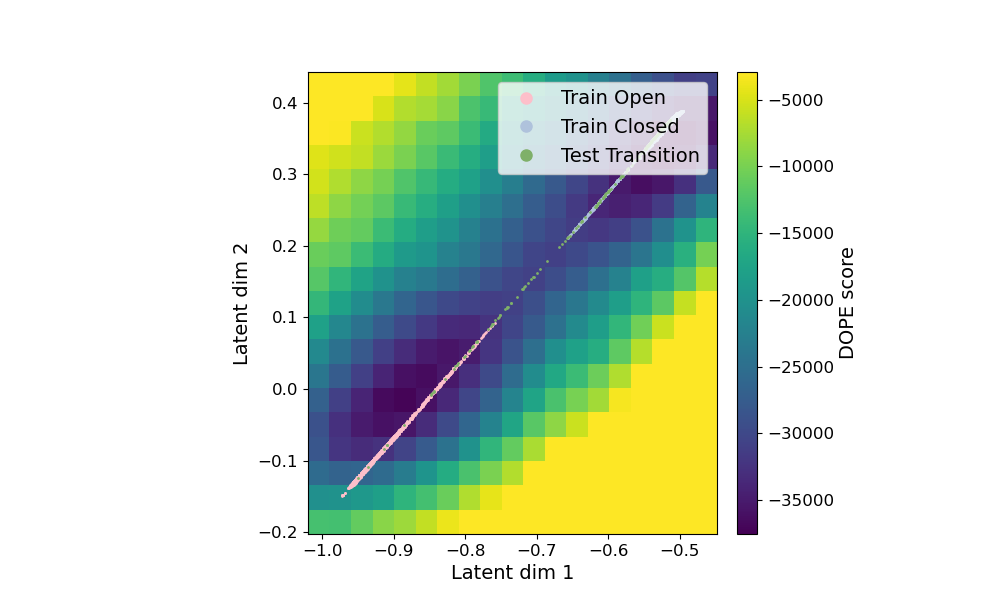

In [10]:
latent_dim = 2

if "grid" not in MAs[latent_dim]._encoded:
    grid_key = MAs[latent_dim].setup_grid(samples=20) #kernel restart is required to change this value
    print(f"Latent grid '{grid_key}' initialised with {MAs[latent_dim].n_samples} samples per axis.")
else:
    grid_key = "grid"
    print("Re-using previously initialised latent grid.")

refine = True

dope_surface, xvals, yvals = MAs[latent_dim].scan_dope(refine=refine)
surface_clip = np.percentile(dope_surface, 80)

dope_plot_data = [
    ("train_open", "Train Open", "#FDBFCA", "scatter"),
    ("train_closed", "Train Closed", "#AFC2DC", "scatter"),
    ("test_trans", "Test Transition", "#7FB069", "scatter"),
]

plot_dope_surface(
    MAs[latent_dim],
    refine=refine,
    truncate_at=surface_clip,
    plot_data=dope_plot_data,
    cmap="viridis",
    bbox_inches="tight",
)

### PCA

Calc Dope: 100%|██████████| 2/2 [00:00<00:00,  9.65it/s]


Latent Dim 2: Total: 100.00%


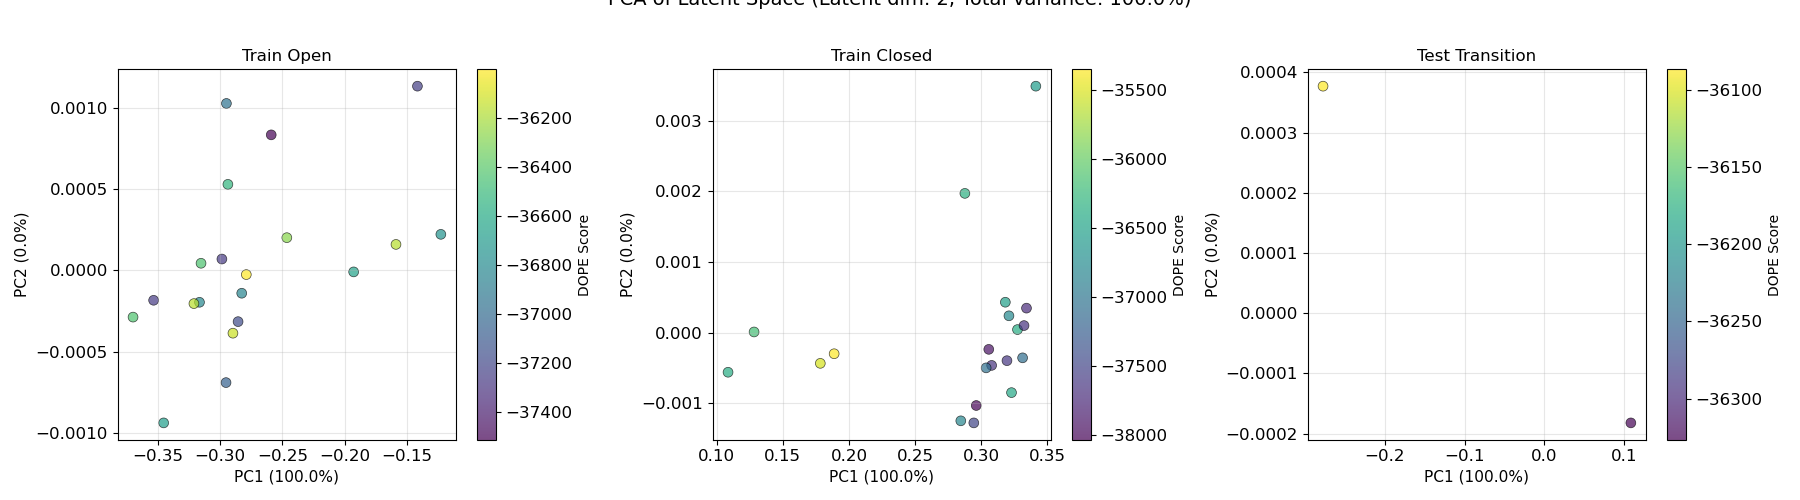

Calc Dope: 100%|██████████| 2/2 [00:00<00:00,  9.50it/s]


Latent Dim 5: Total: 99.98%


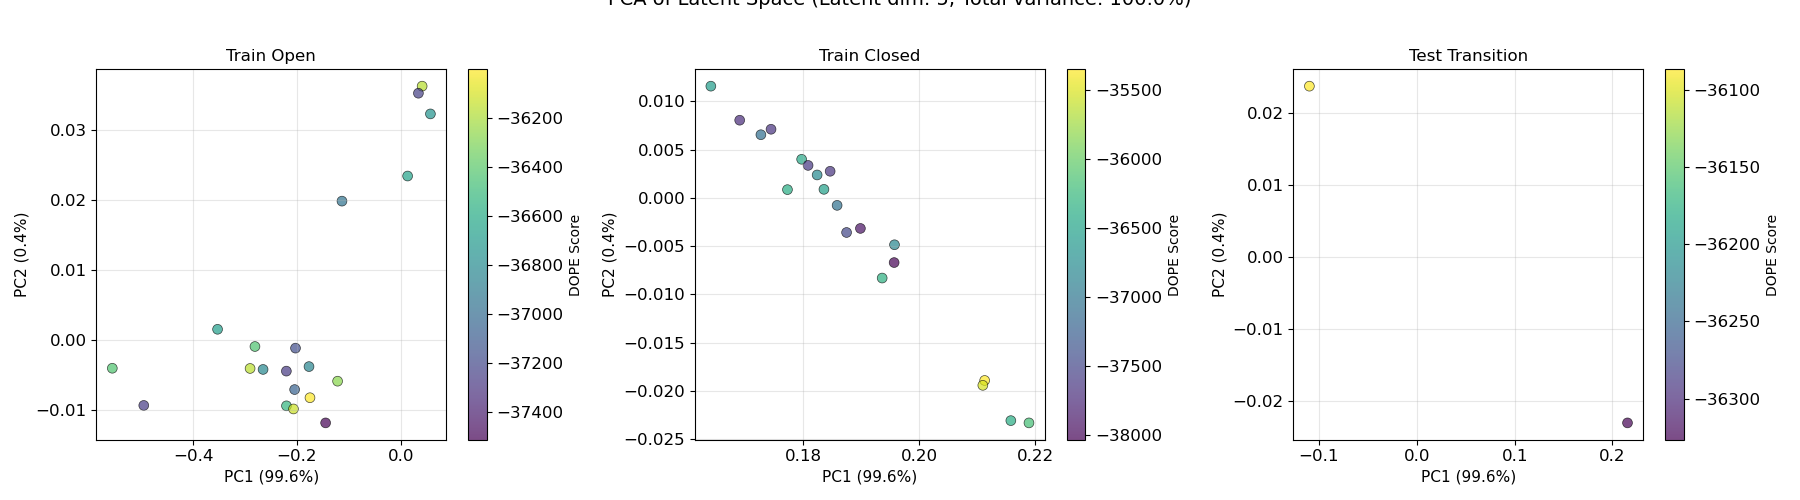

In [ ]:
test_vars = [2, 5]
refine = False
use_partial = True
step=100

dope_scores = {}
pca_results = {}
latent_original_dict = {} 

from sklearn.decomposition import PCA

pcas = {}

keys = ['train_open', 'train_closed', 'test_trans']

for latent_dim in test_vars:

    data = {}
    dope_scores[latent_dim] = {}
    latent_encodings = {}

    # ============================================================
    # getting datasets, dopescores and latent encodings
    # ============================================================

    for key in keys:
        data[key] = MAs[latent_dim].get_dataset(key, scale=True)[::step]
        dope_scores[latent_dim][key]= MAs[latent_dim].get_all_dope_score(data[key], refine=refine)
        latent_encodings[key] = MAs[latent_dim].get_encoded(key)[::step]
    
    # ============================================================
    # Applying PCA
    # ============================================================

    pca = PCA(n_components=2)
    pcas[latent_dim] = pca
    
    latent_all = np.vstack([latent_encodings[key] for key in keys])

    pca.fit(latent_all)

    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    var_total = (var_pc1 + var_pc2)
    
    print(f"Latent Dim {latent_dim}: Total: {var_total:.2f}%")

    pca_results[latent_dim] = {
        'train_open': pca.transform(latent_encodings['train_open']),
        'train_closed': pca.transform(latent_encodings['train_closed']),
        'test_trans': pca.transform(latent_encodings['test_trans']),
        'var_pc1': var_pc1,
        'var_pc2': var_pc2,
        'var_total': var_total,
    }
    
    # =============================================================
    # Plotting data 
    # =============================================================

    plot_data = [
        ('train_open', 'Train Open', '#FDBFCA'),
        ('train_closed', 'Train Closed', '#AFC2DC'),
        ('test_trans', 'Test Transition', '#7FB069'),
    ]
    
    plot_pca_latent_space(
        pca_results[latent_dim],
        dope_scores[latent_dim],
        plot_data=plot_data,
        latent_dim=latent_dim,
    )

### Decoding data from this new PCA space

encoding train_open: 125it [00:00, 226.58it/s]
encoding train_closed: 125it [00:00, 176.85it/s]
encoding test_trans: 13it [00:00, 171.42it/s]


Decoding 17x17 = 289 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 289/289 [00:12<00:00, 23.82it/s]


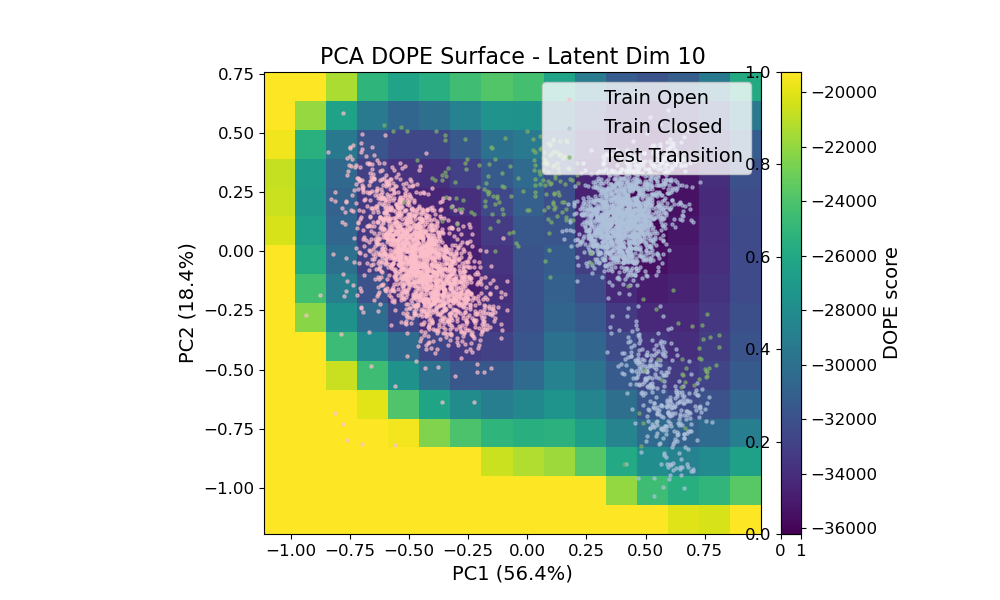

In [14]:


latent_dim = 10
n_samples = 17  # Grid resolution
margin = 0.1    # 10% margin around data
refine = False

# Get all latent codes and fit PCA
latent_all = np.vstack([
    MAs[latent_dim].get_encoded('train_open'),
    MAs[latent_dim].get_encoded('train_closed'),
    MAs[latent_dim].get_encoded('test_trans'),
])
pca = PCA(n_components=2)
pca.fit(latent_all)
pca_all = pca.transform(latent_all)

# Create grid bounds
pc1_min, pc1_max = pca_all[:, 0].min(), pca_all[:, 0].max()
pc2_min, pc2_max = pca_all[:, 1].min(), pca_all[:, 1].max()
pc1_range, pc2_range = pc1_max - pc1_min, pc2_max - pc2_min

pc1_vals = np.linspace(pc1_min - margin*pc1_range, pc1_max + margin*pc1_range, n_samples)
pc2_vals = np.linspace(pc2_min - margin*pc2_range, pc2_max + margin*pc2_range, n_samples)

# Create meshgrid in PCA space
pc1_grid, pc2_grid = np.meshgrid(pc1_vals, pc2_vals)
pca_grid_points = np.column_stack([pc1_grid.ravel(), pc2_grid.ravel()])

# Inverse transform to full latent space
latent_grid = pca.inverse_transform(pca_grid_points)

# Decode ALL points at once
print(f"Decoding {n_samples}x{n_samples} = {n_samples**2} grid points...")
with torch.no_grad():
    latent_tensor = torch.tensor(latent_grid, dtype=torch.float32)
    decoded_all = MAs[latent_dim].network.decode(latent_tensor).numpy()

# Scale back to original coordinates
decoded_scaled = decoded_all * data_open.std + data_open.mean

# Compute DOPE scores for all structures at once
print("Computing DOPE scores...")
dope_grid = MAs[latent_dim].get_all_dope_score(decoded_scaled, refine=refine)


dope_surface = dope_grid.reshape(n_samples, n_samples)

# Plot
def _latent_edge(values):
    return np.append(values, (2 * values[-1] - values[-2]))

surface_clip = np.percentile(dope_surface, 80)

fig, ax = plt.subplots(figsize=(10, 6))

cmap_obj = plt.cm.get_cmap('viridis')
cmap_obj.set_over(cmap_obj(1.0))

mesh = ax.pcolormesh(
    _latent_edge(pc1_vals),
    _latent_edge(pc2_vals),
    dope_surface,
    vmin=dope_surface.min(),
    vmax=surface_clip,
    cmap=cmap_obj,
    shading='auto',
)

ax.set_xlim(pc1_vals.min(), pc1_vals.max())
ax.set_ylim(pc2_vals.min(), pc2_vals.max())
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA DOPE Surface - Latent Dim {latent_dim}')
ax.grid(False)
ax.set_aspect('equal')

# Overlay datasets
pca_open = pca.transform(MAs[latent_dim].get_encoded('train_open'))
pca_closed = pca.transform(MAs[latent_dim].get_encoded('train_closed'))
pca_test = pca.transform(MAs[latent_dim].get_encoded('test_trans'))

ax.scatter(pca_open[:, 0], pca_open[:, 1], c='#FDBFCA', s=5, alpha=0.6, label='Train Open')
ax.scatter(pca_closed[:, 0], pca_closed[:, 1], c='#AFC2DC', s=5, alpha=0.6, label='Train Closed')
ax.scatter(pca_test[:, 0], pca_test[:, 1], c='#7FB069', s=5, alpha=0.6, label='Test Transition')
ax.legend(loc='upper right')

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
])

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
])
cb = fig.colorbar(mesh, cax=cbar_ax)
cb.ax.tick_params(left=False, right=True)
cb.ax.set_ylabel('DOPE score')

plt.show()

### UMAP

encoding train_open: 125it [00:00, 279.34it/s]
encoding train_closed: 125it [00:00, 314.61it/s]
encoding test_trans: 13it [00:00, 296.64it/s]
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fitting UMAP...
Inverse transforming UMAP grid...
Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 3600/3600 [03:13<00:00, 18.61it/s]


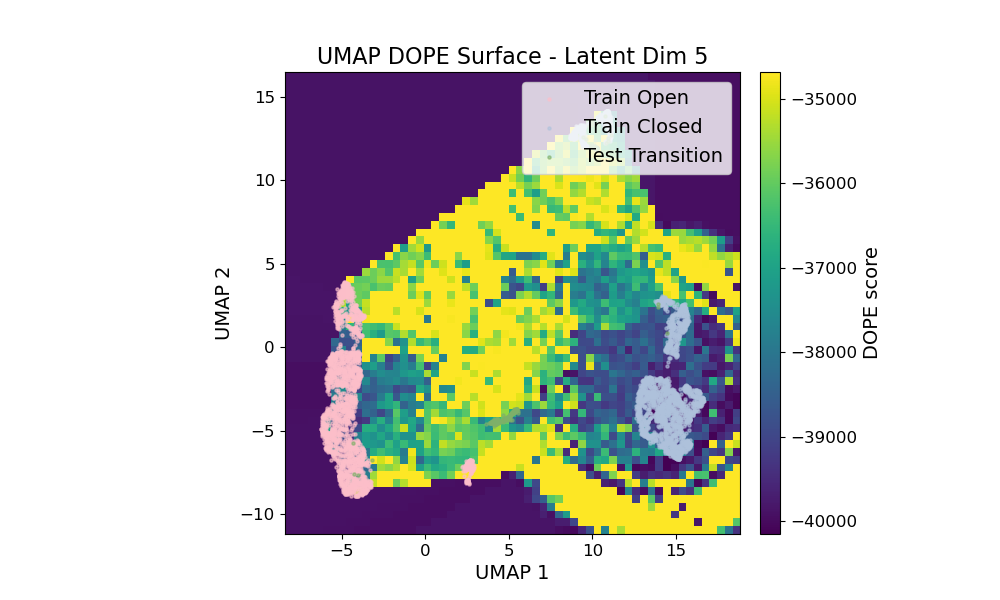

In [3]:
import umap

latent_dim = 5
n_samples = 60  # Grid resolution
margin = 0.1    # 10% margin around data
refine = True

# Get all latent codes
latent_all = np.vstack([
    MAs[latent_dim].get_encoded('train_open'),
    MAs[latent_dim].get_encoded('train_closed'),
    MAs[latent_dim].get_encoded('test_trans'),
])

# Fit UMAP
print("Fitting UMAP...")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(latent_all)

# Create grid bounds in UMAP space
u_min, u_max = embedding[:, 0].min(), embedding[:, 0].max()
v_min, v_max = embedding[:, 1].min(), embedding[:, 1].max()
u_range, v_range = u_max - u_min, v_max - v_min

u_vals = np.linspace(u_min - margin*u_range, u_max + margin*u_range, n_samples)
v_vals = np.linspace(v_min - margin*v_range, v_max + margin*v_range, n_samples)

# Create meshgrid in UMAP space
u_grid, v_grid = np.meshgrid(u_vals, v_vals)
umap_grid_points = np.column_stack([u_grid.ravel(), v_grid.ravel()])

# Inverse transform to full latent space
print("Inverse transforming UMAP grid...")
latent_grid = reducer.inverse_transform(umap_grid_points)

# Decode ALL points at once
print(f"Decoding {n_samples}x{n_samples} = {n_samples**2} grid points...")
with torch.no_grad():
    latent_tensor = torch.tensor(latent_grid, dtype=torch.float32)
    decoded_all = MAs[latent_dim].network.decode(latent_tensor).numpy()

# Scale back to original coordinates
decoded_scaled = decoded_all * data_open.std + data_open.mean

# Compute DOPE scores for all structures at once
print("Computing DOPE scores...")
dope_grid = MAs[latent_dim].get_all_dope_score(decoded_scaled, refine=refine)
dope_surface = dope_grid.reshape(n_samples, n_samples)

# Plot
def _latent_edge(values):
    return np.append(values, (2 * values[-1] - values[-2]))

surface_clip = np.percentile(dope_surface, 80)

fig, ax = plt.subplots(figsize=(10, 6))

cmap_obj = plt.cm.get_cmap('viridis')
cmap_obj.set_over(cmap_obj(1.0))

mesh = ax.pcolormesh(
    _latent_edge(u_vals),
    _latent_edge(v_vals),
    dope_surface,
    vmin=dope_surface.min(),
    vmax=surface_clip,
    cmap=cmap_obj,
    shading='auto',
)

ax.set_xlim(u_vals.min(), u_vals.max())
ax.set_ylim(v_vals.min(), v_vals.max())
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f'UMAP DOPE Surface - Latent Dim {latent_dim}')
ax.grid(False)
ax.set_aspect('equal')

# Overlay datasets - transform each dataset through UMAP
umap_open = reducer.transform(MAs[latent_dim].get_encoded('train_open'))
umap_closed = reducer.transform(MAs[latent_dim].get_encoded('train_closed'))
umap_test = reducer.transform(MAs[latent_dim].get_encoded('test_trans'))

ax.scatter(umap_open[:, 0], umap_open[:, 1], c='#FDBFCA', s=5, alpha=0.6, label='Train Open')
ax.scatter(umap_closed[:, 0], umap_closed[:, 1], c='#AFC2DC', s=5, alpha=0.6, label='Train Closed')
ax.scatter(umap_test[:, 0], umap_test[:, 1], c='#7FB069', s=5, alpha=0.6, label='Test Transition')
ax.legend(loc='upper right')

# Add colorbar
cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
])
cb = fig.colorbar(mesh, cax=cbar_ax)
cb.ax.tick_params(left=False, right=True)
cb.ax.set_ylabel('DOPE score')

plt.show()

### TSNE

encoding train_open: 125it [00:01, 93.35it/s] 
encoding train_closed: 125it [00:00, 128.03it/s]
encoding test_trans: 57it [00:00, 136.22it/s]

Computing DOPE scores...



Calc Dope: 100%|██████████| 490/490 [00:20<00:00, 23.72it/s]


Running t-SNE on 490 points...


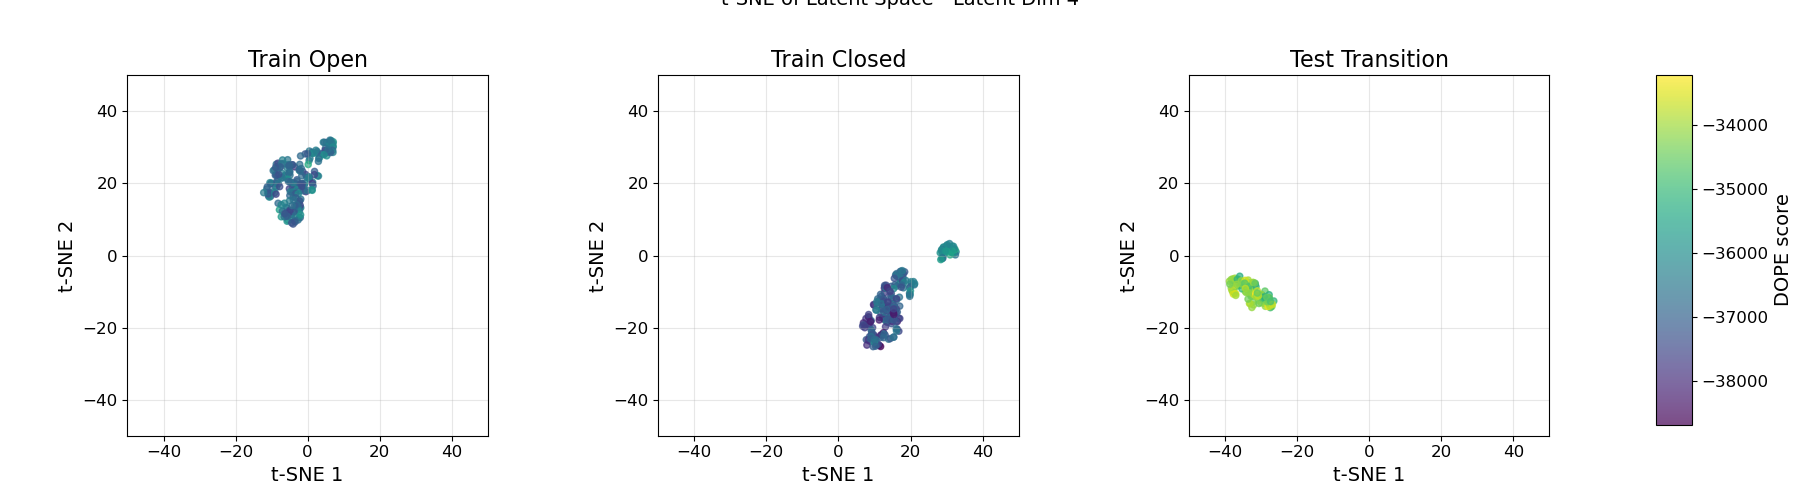

In [4]:
from sklearn.manifold import TSNE

latent_dim = 4
refine = False
step = 10  # Subsample to speed up

# Get subsampled latent codes and structures
latent_open = MAs[latent_dim].get_encoded('train_open')[::step]
latent_closed = MAs[latent_dim].get_encoded('train_closed')[::step]
latent_test = MAs[latent_dim].get_encoded('test_trans')[::step]

data_open_sub = MAs[latent_dim].get_dataset('train_open', scale=True)[::step]
data_closed_sub = MAs[latent_dim].get_dataset('train_closed', scale=True)[::step]
data_test_sub = MAs[latent_dim].get_dataset('test_trans', scale=True)[::step]

latent_all = np.vstack([latent_open, latent_closed, latent_test])
data_all = np.vstack([data_open_sub, data_closed_sub, data_test_sub])

# Track indices for splitting
n_open = len(latent_open)
n_closed = len(latent_closed)
n_test = len(latent_test)

# Compute DOPE scores
print("Computing DOPE scores...")
dope_all = MAs[latent_dim].get_all_dope_score(data_all, refine=refine)

# Split DOPE scores
dope_open = dope_all[:n_open]
dope_closed = dope_all[n_open:n_open + n_closed]
dope_test = dope_all[n_open + n_closed:]

# Fit t-SNE
print(f"Running t-SNE on {len(latent_all)} points...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
embedding = tsne.fit_transform(latent_all)

# Split embeddings
tsne_open = embedding[:n_open]
tsne_closed = embedding[n_open:n_open + n_closed]
tsne_test = embedding[n_open + n_closed:]

# Plot with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Common axis limits and colorbar range
xlim = (-50, 50)
ylim = (-50, 50)
vmin = dope_all.min()
vmax = dope_all.max()

datasets = [
    (tsne_open, dope_open, 'Train Open', '#FDBFCA'),
    (tsne_closed, dope_closed, 'Train Closed', '#AFC2DC'),
    (tsne_test, dope_test, 'Test Transition', '#7FB069'),
]

for ax, (tsne_data, dope_data, title, color) in zip(axes, datasets):
    scatter = ax.scatter(
        tsne_data[:, 0], tsne_data[:, 1],
        c=dope_data, cmap='viridis', s=20, alpha=0.7,
        vmin=vmin, vmax=vmax
    )
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

# Add single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(scatter, cax=cbar_ax)
cb.set_label('DOPE score')

fig.suptitle(f't-SNE of Latent Space - Latent Dim {latent_dim}', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### 3D PCA Plotly

In [8]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

latent_dim = 3

# Get latent encodings
latent_open = MAs[latent_dim].get_encoded('train_open')
latent_closed = MAs[latent_dim].get_encoded('train_closed')
latent_test = MAs[latent_dim].get_encoded('test_trans')
latent_all = np.vstack([latent_open, latent_closed, latent_test])

# Subsample for performance (adjust step as needed)
step = 5
latent_open_sub = latent_open[::step]
latent_closed_sub = latent_closed[::step]
latent_test_sub = latent_test[::step]

# Fit PCA
pca = PCA(n_components=2)
pca.fit(latent_all)

mean = pca.mean_
pc1 = pca.components_[0]
pc2 = pca.components_[1]

# Create PCA plane mesh
grid_range = 3
u = np.linspace(-grid_range, grid_range, 15)
v = np.linspace(-grid_range, grid_range, 15)
U, V = np.meshgrid(u, v)

plane_x = mean[0] + U * pc1[0] + V * pc2[0]
plane_y = mean[1] + U * pc1[1] + V * pc2[1]
plane_z = mean[2] + U * pc1[2] + V * pc2[2]

# Create figure
fig = go.Figure()

# Add data points (subsampled)
fig.add_trace(go.Scatter3d(
    x=latent_open_sub[:, 0], y=latent_open_sub[:, 1], z=latent_open_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#FDBFCA', opacity=0.7),
    name='Train Open'
))
fig.add_trace(go.Scatter3d(
    x=latent_closed_sub[:, 0], y=latent_closed_sub[:, 1], z=latent_closed_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#AFC2DC', opacity=0.7),
    name='Train Closed'
))
fig.add_trace(go.Scatter3d(
    x=latent_test_sub[:, 0], y=latent_test_sub[:, 1], z=latent_test_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#7FB069', opacity=0.7),
    name='Test Transition'
))

# Add PCA plane
fig.add_trace(go.Surface(
    x=plane_x, y=plane_y, z=plane_z,
    opacity=0.4, colorscale=[[0, 'royalblue'], [1, 'royalblue']], 
    showscale=False, name='PCA Plane'
))

# Add PC vectors as lines
arrow_scale = 2
fig.add_trace(go.Scatter3d(
    x=[mean[0], mean[0] + pc1[0]*arrow_scale],
    y=[mean[1], mean[1] + pc1[1]*arrow_scale],
    z=[mean[2], mean[2] + pc1[2]*arrow_scale],
    mode='lines', line=dict(color='red', width=6),
    name=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
))
fig.add_trace(go.Scatter3d(
    x=[mean[0], mean[0] + pc2[0]*arrow_scale],
    y=[mean[1], mean[1] + pc2[1]*arrow_scale],
    z=[mean[2], mean[2] + pc2[2]*arrow_scale],
    mode='lines', line=dict(color='orange', width=6),
    name=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
))

fig.update_layout(
    title=f'3D Latent Space with PCA Plane<br>Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%',
    scene=dict(
        xaxis_title='Latent 1',
        yaxis_title='Latent 2',
        zaxis_title='Latent 3',
        xaxis=dict(range=[-1.5, 1.5]),
        yaxis=dict(range=[-1.5, 1.5]),
        zaxis=dict(range=[-1.5, 1.5]),
        aspectmode='cube'
    ),
    width=800, height=700,
    legend=dict(x=0.02, y=0.98),
)

fig.show()

### Autoencoder